### Load function needed for the program

In [101]:
import pandas as pd
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

### Supress warnings (prevents Jupyter printing out warnings....do be careful with this)

In [102]:
import warnings
warnings.filterwarnings("ignore")

### Define column names of CTD and bottle file

In [103]:
# define column names manually，since column headers of PAR and Fluorescence of the ascii file are printed without spacing, which confuses the read function
column_name_profile = ['Scan','DD','MMM','YYYY','HH:MM:SS','PrdM','Tv290C','C0mS/cm','WetStar','Par','Sbeox0Mm/L','Sbeox0PS','DepSM','Sal00','Sigma-È00','SvCM','Flag']
#column_name_profile = ['Scan','DD','MMM','YYYY','HH:MM:SS','PrdM','Tv290C','C0mS/cm','WetStar','FlECO-AFLPar/sat/log','Sbeox0Mm/L','Sbeox0PS','DepSM','Sal00','Sigma-È00','SvCM','Flag']
column_name_bottle = ['Bottle','Date','Sal00','Sigma-È00','Sbeox0Mm/L','Sbeox0PS','Scan','TimeJ','PrdM','Tv290C','C0mS/cm','WetStar','Par','Note'] 
#['Bottle','Date','Sal00','Sigma-È00','Scan','TimeJ','PrdM','Tv290C','C0mS/cm','WetStar','Par','Sbeox0Mm/L','Note'] 


### Read in the CTD data RE05 Cast 1

In [104]:
# read profile data
#file_name_profile = '2024-05-14/sbe19p_5262_20240514_re5_1m.asc'
file_name_profile = 'CTD_data_day2/sbe55_sbe19p_5262_20260601_re8_1m.asc'
data_profile = pd.read_fwf(file_name_profile, 
                           header=None, 
                           skiprows=1, 
                           names=column_name_profile, 
                           index_col='DepSM',
                           encoding = 'ISO-8859-1',
                           parse_dates={'Time':['YYYY','MMM','DD','HH:MM:SS']}
                          )
# the CTD file contains both upcast and downcast
# to read/plot data individually, seperate two casts by adding a column, titled 'cast_diff'
data_profile['cast_diff'] = data_profile['PrdM'].diff()
data_profile['cast_diff'][0] = 1

In [105]:
data_profile['cast_diff'][data_profile['cast_diff']>=1]=1.
data_profile['cast_diff'][data_profile['cast_diff']<=-1]=-1.

print(data_profile['cast_diff'])

DepSM
0.991    NaN
1.982    1.0
2.973    1.0
3.964    1.0
4.954    1.0
        ... 
4.954   -1.0
3.964   -1.0
2.973   -1.0
1.982   -1.0
0.991   -1.0
Name: cast_diff, Length: 71, dtype: float64


In [106]:
data_profile[(data_profile['cast_diff']==1)]['Tv290C']

DepSM
1.982     10.7361
2.973     10.6563
3.964     10.6047
4.954     10.5332
5.946     10.5112
6.937     10.4999
7.927     10.4652
8.918     10.4175
9.908     10.3922
10.900    10.3686
11.890    10.3376
12.881    10.3119
13.872    10.3033
14.863    10.2948
15.854    10.2823
16.845    10.2612
17.836    10.2579
18.826    10.2491
19.817    10.2170
20.808    10.1921
21.799    10.1880
22.789    10.1884
23.780    10.1757
24.771    10.1648
25.762    10.1509
26.752    10.1321
27.743    10.1285
28.734    10.1224
29.725    10.1150
30.716    10.0862
31.706    10.0657
32.697    10.0515
33.688    10.0332
34.678    10.0112
35.669     9.9802
Name: Tv290C, dtype: float64

### Read in the Bottle data RE05 Cast 1

In [107]:
# read bottle data
#file_name_bottle = '2024-05-14/sbe19p_5262_20240514_re5.btl'
file_name_bottle = 'CTD_data_day2/sbe55_sbe19p_5262_20260601_re8.btl'
data_bottle = pd.read_fwf(file_name_bottle, 
                          header=None, 
                          skiprows=162,
                          names=column_name_bottle,
                          encoding='latin-1')


# select the average and std
data_bottle_average = data_bottle[data_bottle['Note']=='(avg)'].reset_index(drop=True)
data_bottle_std = data_bottle[data_bottle['Note']=='(sdev)'].reset_index(drop=True)

### Plot bottle data onto CTD data RE05 Cast 1

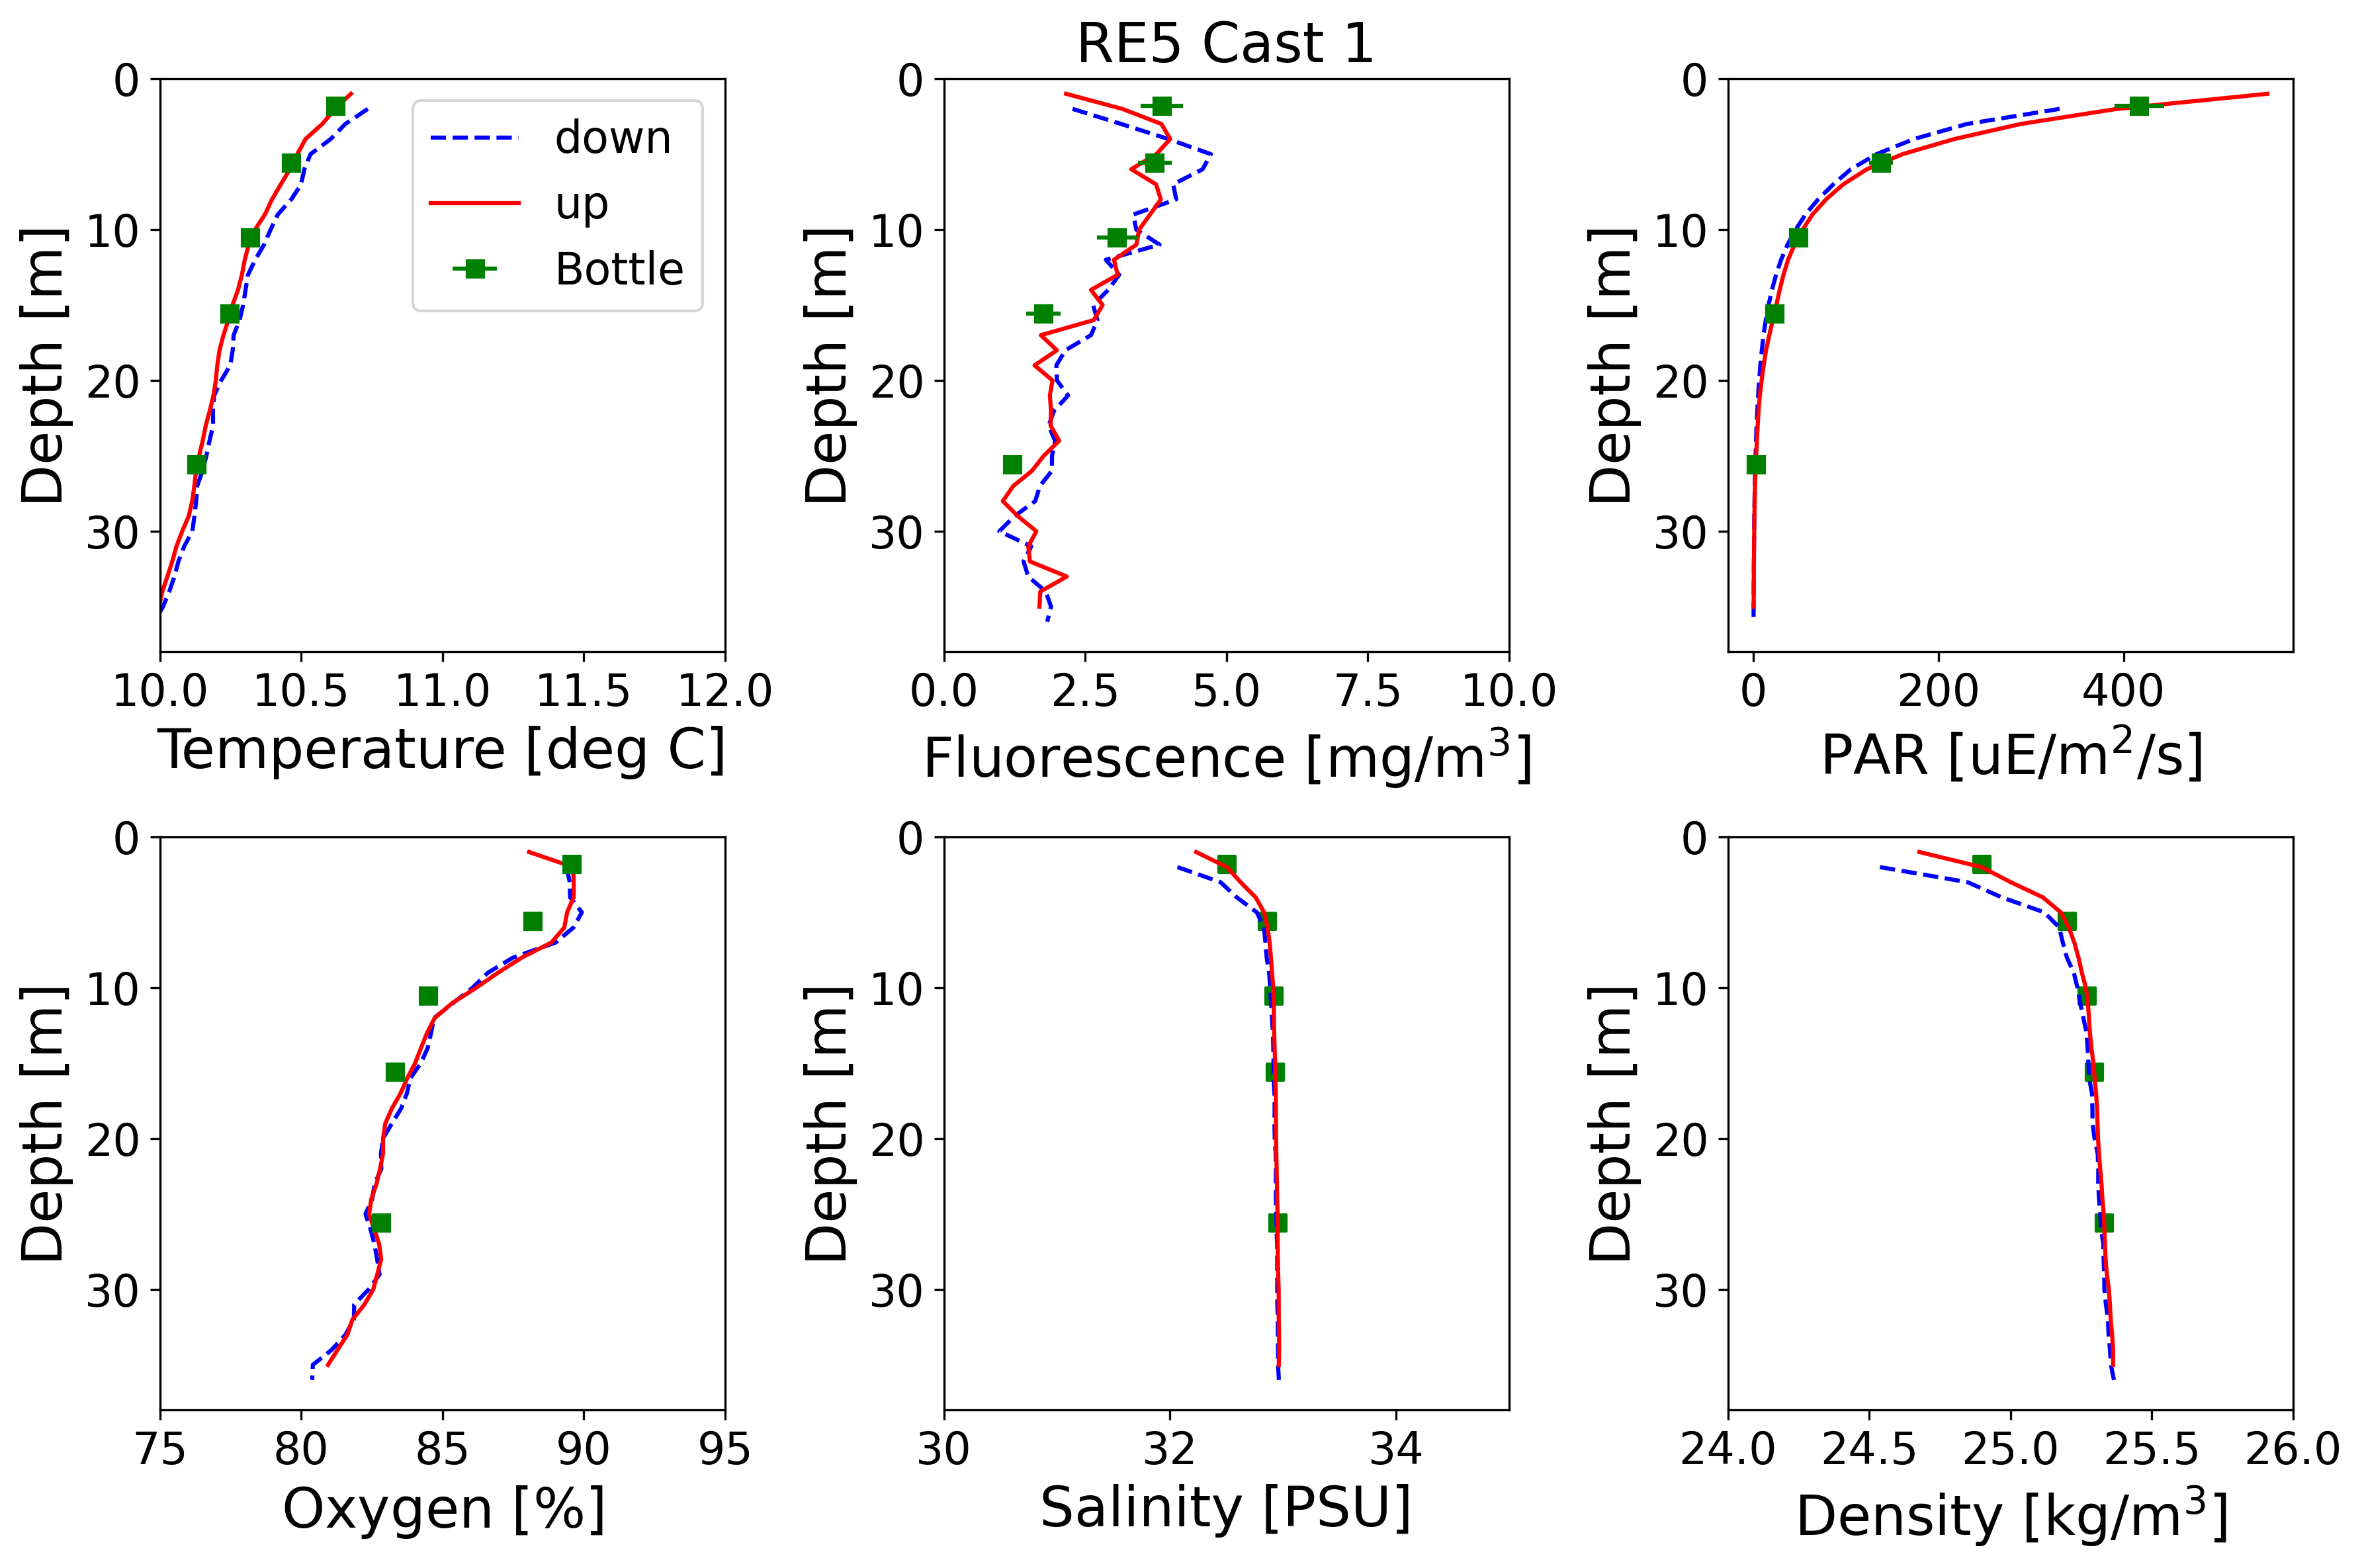

In [36]:
# plot both profile and bottle data
fig, axes = plt.subplots(nrows=2,ncols=3,figsize=(12,8),dpi=300)

# temperature
axes[0,0].plot(data_profile[(data_profile['cast_diff']==1)]['Tv290C'],data_profile[(data_profile['cast_diff']==1)]['PrdM'],'b--', label='down')
axes[0,0].plot(data_profile[(data_profile['cast_diff']==-1)]['Tv290C'],data_profile[(data_profile['cast_diff']==-1)]['PrdM'],'r-', label='up')
axes[0,0].errorbar(data_bottle_average['Tv290C'],data_bottle_average['PrdM'],xerr=data_bottle_std['Tv290C'],marker='s',color='green',ls='None',label='Bottle')
axes[0,0].set_ylim([0,np.max(data_profile['PrdM'])+2])
axes[0,0].set_xlim([10,12])
axes[0,0].invert_yaxis()
axes[0,0].set_xlabel('Temperature [deg C]', fontsize = 20)
axes[0,0].set_ylabel('Depth [m]', fontsize = 20)
axes[0,0].xaxis.set_tick_params(labelsize=16)
axes[0,0].yaxis.set_tick_params(labelsize=16)
axes[0,0].legend(fontsize = 16)   

# fluorescence
axes[0,1].plot(data_profile[(data_profile['cast_diff']==1)]['WetStar'],data_profile[(data_profile['cast_diff']==1)]['PrdM'],'b--', label='down')
axes[0,1].plot(data_profile[(data_profile['cast_diff']==-1)]['WetStar'],data_profile[(data_profile['cast_diff']==-1)]['PrdM'],'r-', label='up')
axes[0,1].errorbar(data_bottle_average['WetStar'],data_bottle_average['PrdM'],xerr=data_bottle_std['WetStar'],marker='s',color='green',ls='None',label='Bottle')
axes[0,1].set_ylim([0,np.max(data_profile['PrdM'])+2])
axes[0,1].set_xlim([0,10])
axes[0,1].invert_yaxis()
axes[0,1].set_xlabel('Fluorescence [mg/m$^3$]', fontsize = 20)
axes[0,1].set_ylabel('Depth [m]', fontsize = 20)
axes[0,1].set_title('RE5 Cast 1', fontsize = 20)
axes[0,1].xaxis.set_tick_params(labelsize=16)
axes[0,1].yaxis.set_tick_params(labelsize=16)
# axes[0,1].legend(fontsize = 16)   

# PAR
axes[0,2].plot(data_profile[(data_profile['cast_diff']==1)]['Par'],data_profile[(data_profile['cast_diff']==1)]['PrdM'],'b--', label='down')
axes[0,2].plot(data_profile[(data_profile['cast_diff']==-1)]['Par'],data_profile[(data_profile['cast_diff']==-1)]['PrdM'],'r-', label='up')
axes[0,2].errorbar(data_bottle_average['Par'],data_bottle_average['PrdM'],xerr=data_bottle_std['Par'],marker='s',color='green',ls='None',label='Bottle')
axes[0,2].set_ylim([0,np.max(data_profile['PrdM'])+2])
axes[0,2].invert_yaxis()
axes[0,2].set_xlabel('PAR [uE/m$^2$/s]', fontsize = 20)
axes[0,2].set_ylabel('Depth [m]', fontsize = 20)
axes[0,2].xaxis.set_tick_params(labelsize=16)
axes[0,2].yaxis.set_tick_params(labelsize=16)
# axes[0,2].legend(fontsize = 16)   

# Oxygen
axes[1,0].plot(data_profile[(data_profile['cast_diff']==1)]['Sbeox0PS'],data_profile[(data_profile['cast_diff']==1)]['PrdM'],'b--', label='down')
axes[1,0].plot(data_profile[(data_profile['cast_diff']==-1)]['Sbeox0PS'],data_profile[(data_profile['cast_diff']==-1)]['PrdM'],'r-', label='up')
axes[1,0].errorbar(data_bottle_average['Sbeox0PS'],data_bottle_average['PrdM'],xerr=data_bottle_std['Sbeox0PS'],marker='s',color='green',ls='None',label='Bottle')
axes[1,0].set_ylim([0,np.max(data_profile['PrdM'])+2])
#axes[1,0].set_xlim([200,300])
axes[1,0].set_xlim([75,95])
axes[1,0].invert_yaxis()
axes[1,0].set_xlabel('Oxygen [$\%$]', fontsize = 20)
axes[1,0].set_ylabel('Depth [m]', fontsize = 20)
axes[1,0].xaxis.set_tick_params(labelsize=16)
axes[1,0].yaxis.set_tick_params(labelsize=16)
# axes[1,0].legend(fontsize = 16)    

# Salinity
axes[1,1].plot(data_profile[(data_profile['cast_diff']==1)]['Sal00'],data_profile[(data_profile['cast_diff']==1)]['PrdM'],'b--', label='down')
axes[1,1].plot(data_profile[(data_profile['cast_diff']==-1)]['Sal00'],data_profile[(data_profile['cast_diff']==-1)]['PrdM'],'r-', label='up')
axes[1,1].scatter(data_bottle_average['Sal00'],data_bottle_average['PrdM'],marker='s',color='green',label='Bottle')
axes[1,1].set_ylim([0,np.max(data_profile['PrdM'])+2])
axes[1,1].set_xlim([30,35])
axes[1,1].invert_yaxis()
axes[1,1].set_xlabel('Salinity [PSU]', fontsize = 20)
axes[1,1].set_ylabel('Depth [m]', fontsize = 20)
axes[1,1].xaxis.set_tick_params(labelsize=16)
axes[1,1].yaxis.set_tick_params(labelsize=16)
# axes[1,1].legend(fontsize = 16)    

# Density 
axes[1,2].plot(data_profile[(data_profile['cast_diff']==1)]['Sigma-È00'],data_profile[(data_profile['cast_diff']==1)]['PrdM'],'b--', label='down')
axes[1,2].plot(data_profile[(data_profile['cast_diff']==-1)]['Sigma-È00'],data_profile[(data_profile['cast_diff']==-1)]['PrdM'],'r-', label='up')
axes[1,2].scatter(data_bottle_average['Sigma-È00'],data_bottle_average['PrdM'],marker='s',color='green',label='Bottle')
axes[1,2].set_ylim([0,np.max(data_profile['PrdM'])+2])
axes[1,2].set_xlim([24,26])
axes[1,2].invert_yaxis()
axes[1,2].set_xlabel('Density [kg/m$^3$]', fontsize = 20)
axes[1,2].set_ylabel('Depth [m]', fontsize = 20)
axes[1,2].xaxis.set_tick_params(labelsize=16)
axes[1,2].yaxis.set_tick_params(labelsize=16)
# axes[1,2].legend(fontsize = 16) 

fig.tight_layout()

### Read in the Bottle data for all stations

In [21]:
# read profile data
file_name_profile_list = ['CTD_data_day2/sbe55_sbe19p_5262_20260601_re4_1m.asc',
                          'CTD_data_day2/sbe55_sbe19p_5262_20260601_re5_1m.asc',
                          'CTD_data_day2/sbe55_sbe19p_5262_20260601_re6_1m.asc',
                          'CTD_data_day2/sbe55_sbe19p_5262_20260601_re7_1m.asc',
                          'CTD_data_day2/sbe55_sbe19p_5262_20260601_re7pt5_1m.asc',
                          'CTD_data_day2/sbe55_sbe19p_5262_20260601_re8_1m.asc',
                          'CTD_data_day2/sbe55_sbe19p_5262_20260601_re9_1m.asc',                          
                         ]

file_name_bottle_list = [
                          'CTD_data_day2/sbe55_sbe19p_5262_20260601_re8.btl'                          
                         ]

def read_ctd_data(file_name_profile):
    data_profile = pd.read_fwf(file_name_profile, 
                           header=None, 
                           skiprows=1, 
                           names=column_name_profile, 
                           index_col='DepSM',
                           encoding = 'ISO-8859-1',
                           parse_dates={'Time':['YYYY','MMM','DD','HH:MM:SS']}
                          )

    # the CTD file contains both upcast and downcast
    # to read/plot data individually, seperate two casts by adding a column, titled 'cast_diff'
    data_profile['cast_diff'] = data_profile['PrdM'].diff()
    data_profile['cast_diff'][0] = 1
    data_profile['cast_diff'][data_profile['cast_diff']>=1]=1.
    data_profile['cast_diff'][data_profile['cast_diff']<=-1]=-1.

    return data_profile

def read_bottle_data(file_name_bottle):
    # read bottle data
    data_bottle = pd.read_fwf(file_name_bottle, 
                          header=None, 
                          skiprows=162,
                          names=column_name_bottle,
                          encoding='latin-1')


    # select the average and std
    data_bottle_average = data_bottle[data_bottle['Note']=='(avg)'].reset_index(drop=True)
    data_bottle_std = data_bottle[data_bottle['Note']=='(sdev)'].reset_index(drop=True)

    return data_bottle_average, data_bottle_std
    

In [115]:
#load ctd
data_profile_list = []
for nn in np.arange(len(file_name_profile_list)):
    print(file_name_profile)
    data_profile = read_ctd_data(file_name_profile_list[nn])
    data_profile_list.append(data_profile)


#load bottle
print(' ')
data_bottle_avg_list, data_bottle_std_list = [],[]
file_name_bottle = file_name_bottle_list[0]
print(file_name_bottle)
data_bottle_avg, data_bottle_std = read_bottle_data(file_name_bottle)
data_bottle_avg_list.append(data_bottle_avg)
data_bottle_std_list.append(data_bottle_std)  
        

print(data_bottle_avg_list)

CTD_data_day2/sbe55_sbe19p_5262_20260601_re8_1m.asc
CTD_data_day2/sbe55_sbe19p_5262_20260601_re8_1m.asc
CTD_data_day2/sbe55_sbe19p_5262_20260601_re8_1m.asc
CTD_data_day2/sbe55_sbe19p_5262_20260601_re8_1m.asc
CTD_data_day2/sbe55_sbe19p_5262_20260601_re8_1m.asc
CTD_data_day2/sbe55_sbe19p_5262_20260601_re8_1m.asc
CTD_data_day2/sbe55_sbe19p_5262_20260601_re8_1m.asc
 


NameError: name 'file_name_bottle_list' is not defined

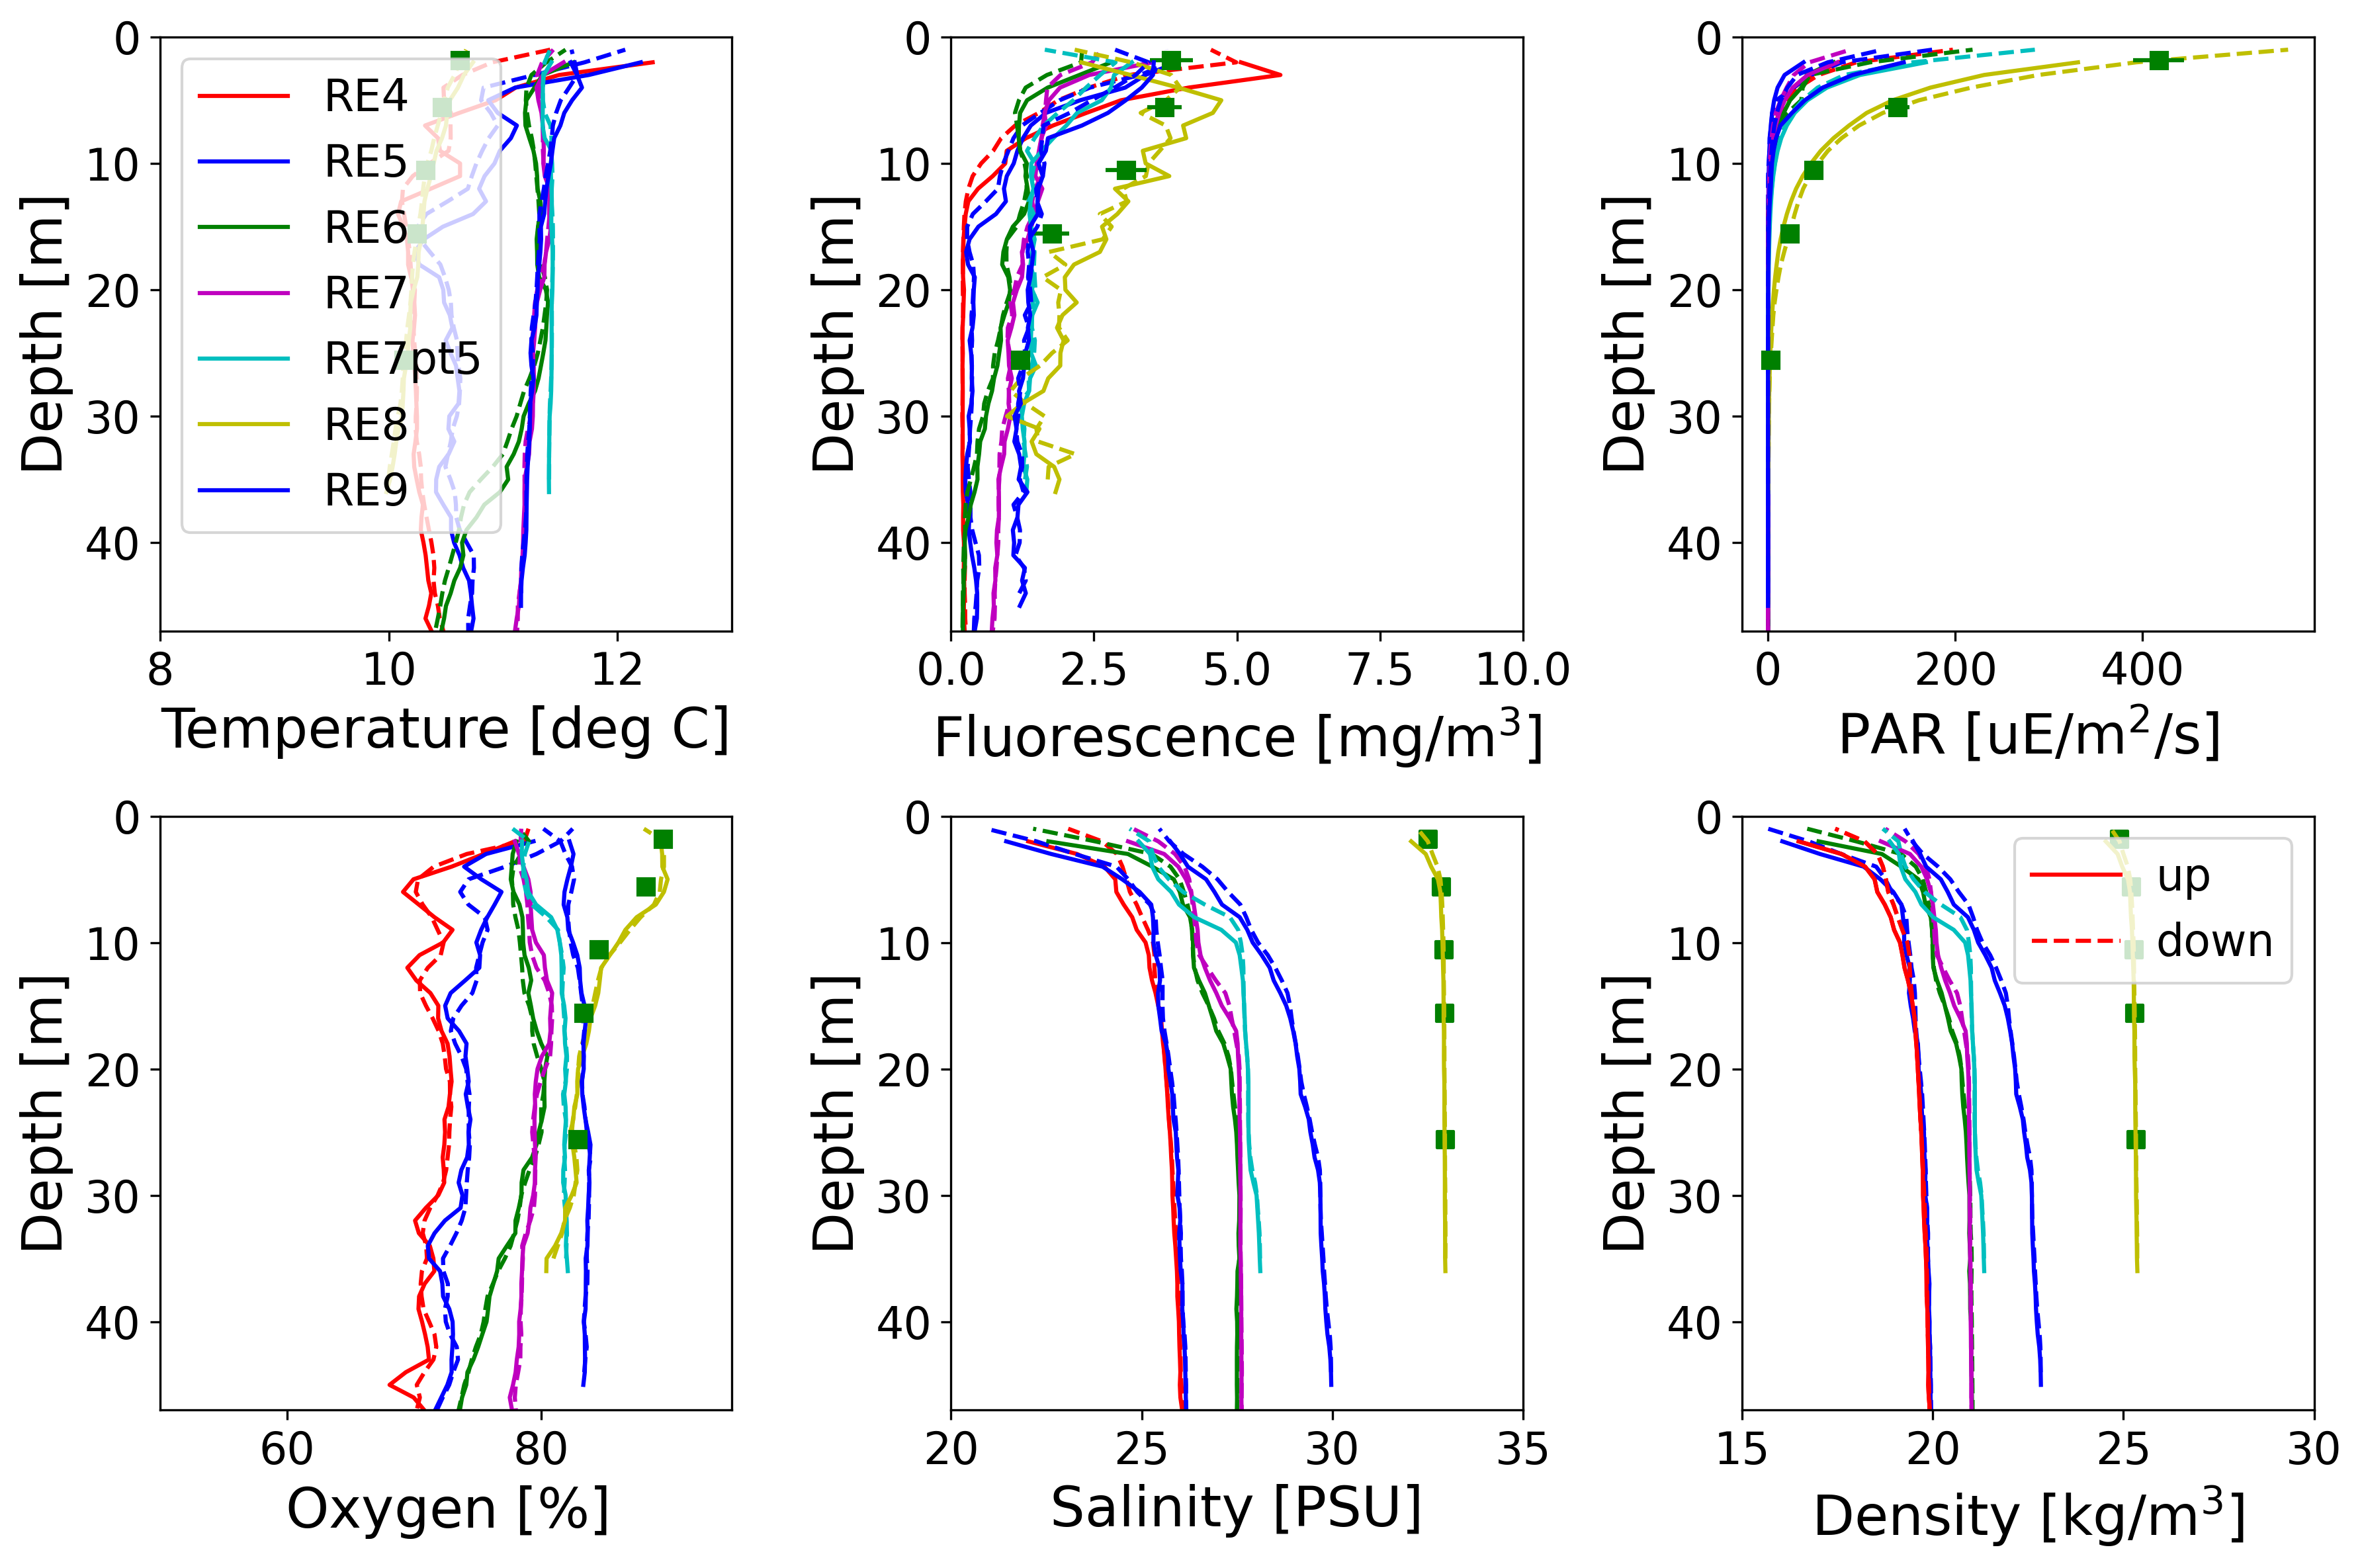

In [38]:
# plot both profile and bottle data
fig, axes = plt.subplots(nrows=2,ncols=3,figsize=(12,8),dpi=300)

linestyle_list_up = ['r-','b-','g-','m-','c-','y-','b-']
linestyle_list_do = ['r--','b--','g--','m--','c--','y--','b--']
label_list = ['RE4','RE5','RE6','RE7','RE7pt5','RE8','RE9']

for nn in np.arange(len(data_profile_list)):

    # temperature
    axes[0,0].plot(data_profile_list[nn][(data_profile_list[nn]['cast_diff']==1)]['Tv290C'],data_profile_list[nn][(data_profile_list[nn]['cast_diff']==1)]['PrdM'],linestyle_list_up[nn], label=label_list[nn])
    axes[0,0].plot(data_profile_list[nn][(data_profile_list[nn]['cast_diff']==-1)]['Tv290C'],data_profile_list[nn][(data_profile_list[nn]['cast_diff']==-1)]['PrdM'],linestyle_list_do[nn])
    if nn in [5]:
       axes[0,0].errorbar(data_bottle_avg_list[0]['Tv290C'],data_bottle_avg_list[0]['PrdM'],xerr=data_bottle_std_list[0]['Tv290C'],marker='s',color='green',ls='None')
    
    axes[0,0].set_ylim([0,np.max(data_profile_list[nn]['PrdM'])+2])
    axes[0,0].set_xlim([8,13])
    axes[0,0].invert_yaxis()
    axes[0,0].set_xlabel('Temperature [deg C]', fontsize = 20)
    axes[0,0].set_ylabel('Depth [m]', fontsize = 20)
    axes[0,0].xaxis.set_tick_params(labelsize=16)
    axes[0,0].yaxis.set_tick_params(labelsize=16)
    axes[0,0].legend(fontsize = 16)   

    # fluorescence
    axes[0,1].plot(data_profile_list[nn][(data_profile_list[nn]['cast_diff']==1)]['WetStar'],data_profile_list[nn][(data_profile_list[nn]['cast_diff']==1)]['PrdM'],linestyle_list_up[nn])
    axes[0,1].plot(data_profile_list[nn][(data_profile_list[nn]['cast_diff']==-1)]['WetStar'],data_profile_list[nn][(data_profile_list[nn]['cast_diff']==-1)]['PrdM'],linestyle_list_do[nn])
    if nn in [5]:
       axes[0,1].errorbar(data_bottle_avg_list[0]['WetStar'],data_bottle_avg_list[0]['PrdM'],xerr=data_bottle_std_list[0]['WetStar'],marker='s',color='green',ls='None')
    axes[0,1].set_ylim([0,np.max(data_profile_list[nn]['PrdM'])+2])
    axes[0,1].set_xlim([0,10])
    axes[0,1].invert_yaxis()
    axes[0,1].set_xlabel('Fluorescence [mg/m$^3$]', fontsize = 20)
    axes[0,1].set_ylabel('Depth [m]', fontsize = 20)
    #axes[0,1].set_title('RE8 Cast 1', fontsize = 20)
    axes[0,1].xaxis.set_tick_params(labelsize=16)
    axes[0,1].yaxis.set_tick_params(labelsize=16)
    # axes[0,1].legend(fontsize = 16)   

    # PAR
    axes[0,2].plot(data_profile_list[nn][(data_profile_list[nn]['cast_diff']==1)]['Par'],data_profile_list[nn][(data_profile_list[nn]['cast_diff']==1)]['PrdM'],linestyle_list_up[nn])
    axes[0,2].plot(data_profile_list[nn][(data_profile_list[nn]['cast_diff']==-1)]['Par'],data_profile_list[nn][(data_profile_list[nn]['cast_diff']==-1)]['PrdM'],linestyle_list_do[nn])
    if nn in [5]:
       axes[0,2].errorbar(data_bottle_avg_list[0]['Par'],data_bottle_avg_list[0]['PrdM'],xerr=data_bottle_std_list[0]['Par'],marker='s',color='green',ls='None')
    axes[0,2].set_ylim([0,np.max(data_profile_list[nn]['PrdM'])+2])
    axes[0,2].invert_yaxis()
    axes[0,2].set_xlabel('PAR [uE/m$^2$/s]', fontsize = 20)
    axes[0,2].set_ylabel('Depth [m]', fontsize = 20)
    axes[0,2].xaxis.set_tick_params(labelsize=16)
    axes[0,2].yaxis.set_tick_params(labelsize=16)
    # axes[0,2].legend(fontsize = 16)   

    # Oxygen
    axes[1,0].plot(data_profile_list[nn][(data_profile_list[nn]['cast_diff']==1)]['Sbeox0PS'],data_profile_list[nn][(data_profile_list[nn]['cast_diff']==1)]['PrdM'],linestyle_list_up[nn])
    axes[1,0].plot(data_profile_list[nn][(data_profile_list[nn]['cast_diff']==-1)]['Sbeox0PS'],data_profile_list[nn][(data_profile_list[nn]['cast_diff']==-1)]['PrdM'],linestyle_list_do[nn])
    if nn in [5]:
       axes[1,0].errorbar(data_bottle_avg_list[0]['Sbeox0PS'],data_bottle_avg_list[0]['PrdM'],xerr=data_bottle_std_list[0]['Sbeox0PS'],marker='s',color='green',ls='None')
    axes[1,0].set_ylim([0,np.max(data_profile_list[nn]['PrdM'])+2])
    axes[1,0].set_xlim([50,95])
    axes[1,0].invert_yaxis()
    axes[1,0].set_xlabel('Oxygen [$\%$]', fontsize = 20)
    axes[1,0].set_ylabel('Depth [m]', fontsize = 20)
    axes[1,0].xaxis.set_tick_params(labelsize=16)
    axes[1,0].yaxis.set_tick_params(labelsize=16)
    # axes[1,0].legend(fontsize = 16)    

    # Salinity
    axes[1,1].plot(data_profile_list[nn][(data_profile_list[nn]['cast_diff']==1)]['Sal00'],data_profile_list[nn][(data_profile_list[nn]['cast_diff']==1)]['PrdM'],linestyle_list_up[nn])
    axes[1,1].plot(data_profile_list[nn][(data_profile_list[nn]['cast_diff']==-1)]['Sal00'],data_profile_list[nn][(data_profile_list[nn]['cast_diff']==-1)]['PrdM'],linestyle_list_do[nn])
    if nn in [5]:
       axes[1,1].scatter(data_bottle_avg_list[0]['Sal00'],data_bottle_avg_list[0]['PrdM'],marker='s',color='green')
    axes[1,1].set_ylim([0,np.max(data_profile_list[nn]['PrdM'])+2])
    axes[1,1].invert_yaxis()
    axes[1,1].set_xlim([20,35])
    axes[1,1].set_xlabel('Salinity [PSU]', fontsize = 20)
    axes[1,1].set_ylabel('Depth [m]', fontsize = 20)
    axes[1,1].xaxis.set_tick_params(labelsize=16)
    axes[1,1].yaxis.set_tick_params(labelsize=16)
    # axes[1,1].legend(fontsize = 16)    

    # Density 
    axes[1,2].plot(data_profile_list[nn][(data_profile_list[nn]['cast_diff']==1)]['Sigma-È00'],data_profile_list[nn][(data_profile_list[nn]['cast_diff']==1)]['PrdM'],linestyle_list_up[nn])
    axes[1,2].plot(data_profile_list[nn][(data_profile_list[nn]['cast_diff']==-1)]['Sigma-È00'],data_profile_list[nn][(data_profile_list[nn]['cast_diff']==-1)]['PrdM'],linestyle_list_do[nn])
    if nn in [5]:
       axes[1,2].scatter(data_bottle_avg_list[0]['Sigma-È00'],data_bottle_avg_list[0]['PrdM'],marker='s',color='green')
    axes[1,2].set_ylim([0,np.max(data_profile_list[nn]['PrdM'])+2])
    axes[1,2].set_xlim([15,30])
    axes[1,2].invert_yaxis()
    axes[1,2].set_xlabel('Density [kg/m$^3$]', fontsize = 20)
    axes[1,2].set_ylabel('Depth [m]', fontsize = 20)
    axes[1,2].xaxis.set_tick_params(labelsize=16)
    axes[1,2].yaxis.set_tick_params(labelsize=16)
    # axes[1,2].legend(fontsize = 16) 


axes[1,2].plot(data_profile_list[0][(data_profile_list[0]['cast_diff']==1)]['Sigma-È00'],data_profile_list[0][(data_profile_list[0]['cast_diff']==1)]['PrdM'],linestyle_list_up[0],label='up')
axes[1,2].plot(data_profile_list[0][(data_profile_list[0]['cast_diff']==-1)]['Sigma-È00'],data_profile_list[0][(data_profile_list[0]['cast_diff']==-1)]['PrdM'],linestyle_list_do[0],label='down')
#axes[1,2].scatter(data_bottle_avg_list[0]['Sigma-È00'],data_bottle_avg_list[0]['PrdM'],marker='s',color='green',label='Bottles')
axes[1,2].legend(fontsize = 16) 


fig.tight_layout()





In [108]:
etive_log = pd.read_excel('CTD_data_day2/Etive_lon_lat.xlsx')
etive_log_lat_lon = etive_log[['lat_dec','lon_dec']]
print(etive_log_lat_lon)

   lat_dec  lon_dec
0    56.28    -5.10
1    56.27    -5.11
2    56.26    -5.14
3    56.27    -5.16
4    56.27    -5.18
5    56.27    -5.20
6    56.27    -5.26


In [109]:
all_temperature  = pd.DataFrame()
all_fluorescence = pd.DataFrame()
all_par          = pd.DataFrame()
all_oxygen       = pd.DataFrame()
all_salinity     = pd.DataFrame()
all_density      = pd.DataFrame()
print(etive_log['CTD_NAME'])
print(all_temperature)

0       sbe55_sbe19p_5262_20260601_re4_1m.asc
1       sbe55_sbe19p_5262_20260601_re5_1m.asc
2       sbe55_sbe19p_5262_20260601_re6_1m.asc
3       sbe55_sbe19p_5262_20260601_re7_1m.asc
4    sbe55_sbe19p_5262_20260601_re7pt5_1m.asc
5       sbe55_sbe19p_5262_20260601_re9_1m.asc
6       sbe55_sbe19p_5262_20260601_re8_1m.asc
Name: CTD_NAME, dtype: object
Empty DataFrame
Columns: []
Index: []


In [110]:
## Temperature 
cmap_temp = plt.cm.get_cmap('jet')
norm_temp = mpl.colors.Normalize(vmin=9, vmax=13)

## Fluoroscence 
cmap_fluo = plt.cm.get_cmap('viridis')
norm_fluo = mpl.colors.Normalize(vmin=1, vmax=5)

## PAR
cmap_par = plt.cm.get_cmap('Oranges')
norm_par = mpl.colors.Normalize(vmin=np.log10(1), vmax=np.log10(1500)) 

## Oxygen
cmap_oxygen = plt.cm.get_cmap('RdYlBu_r')
norm_oxygen = mpl.colors.Normalize(vmin=50, vmax=100) 

## Salinity
cmap_sal = plt.cm.get_cmap('jet')
norm_sal = mpl.colors.Normalize(vmin=24, vmax=35) 

## Density
cmap_density = plt.cm.get_cmap('rainbow')
norm_density = mpl.colors.Normalize(vmin=20, vmax=28)

In [112]:
for file_name in etive_log['CTD_NAME']:
    data_profile = pd.read_fwf('CTD_data_day2/'+file_name, 
                               header=None, 
                               skiprows=1, 
                               names=column_name_profile, 
                               index_col='PrdM',
                               encoding = 'ISO-8859-1',
                               parse_dates={'Time':['YYYY','MMM','DD','HH:MM:SS']})
    
    # calculate the difference of depth, so that define the upcast and downcast
    data_profile['cast_diff'] = data_profile['DepSM'].diff()
    data_profile['cast_diff'].iloc[0] = 1
    data_profile = data_profile[data_profile['cast_diff'] >= 0]

    #get depths for the vertical interpolation
    ZZ_old = np.array(data_profile['DepSM'])
    ZZ_new = np.arange(ZZ_old[0], ZZ_old[-1]+1,1)
    print(ZZ_old.shape, ZZ_new.shape)
    print(ZZ_old[0], ZZ_old[-1])
    print(ZZ_new[0], ZZ_new[-1])
    
    #temperature
    temp_old = np.array(data_profile['Tv290C'])
    temp_new = np.interp(ZZ_new, ZZ_old, temp_old )
    temp_new = pd.DataFrame(temp_new)
    # concat the temp file in the loop for each CTD file
    all_temperature = pd.concat([all_temperature, temp_new], axis=1)
    # rename the column name to the station name
    all_temperature.rename(columns={'Tv290C': file_name}, inplace=True)

    ## fluorescence
    fluo_old = np.array(data_profile['WetStar'])
    fluo_new = np.interp(ZZ_new, ZZ_old, fluo_old )
    fluo_new = pd.DataFrame(fluo_new)
    # concat the file in the loop for each CTD file
    all_fluorescence = pd.concat([all_fluorescence, fluo_new], axis=1)
    all_fluorescence.rename(columns={'WetStar': file_name}, inplace=True)

    ## PAR
    par_old = np.array(data_profile['Par'])
    par_new = np.interp(ZZ_new, ZZ_old, par_old )
    par_new = pd.DataFrame(par_new)
    # concat the file in the loop for each CTD file
    all_par = pd.concat([all_par, par_new], axis=1)
    all_par.rename(columns={'Par': file_name}, inplace=True)
    
    ## oxygen
    oxy_old = np.array(data_profile['Sbeox0PS'])
    oxy_new = np.interp(ZZ_new, ZZ_old, oxy_old )
    oxy_new = pd.DataFrame(oxy_new)
    all_oxygen = pd.concat([all_oxygen, oxy_new], axis=1)
    all_oxygen.rename(columns={'Sbeox0PS': file_name}, inplace=True)
    
    ## salinity
    sal_old = np.array(data_profile['Sal00'])
    sal_new = np.interp(ZZ_new, ZZ_old, sal_old )
    sal_new = pd.DataFrame(sal_new)
    all_salinity = pd.concat([all_salinity, sal_new], axis=1)
    all_salinity.rename(columns={'Sal00': file_name}, inplace=True)
    
    ## density
    dens_old = np.array(data_profile['Sigma-È00'])
    dens_new = np.interp(ZZ_new, ZZ_old, dens_old )
    dens_new = pd.DataFrame(dens_new)
    all_density = pd.concat([all_density, dens_new], axis=1)
    all_density.rename(columns={'Sigma-È00': file_name}, inplace=True)

    print(file_name)

(122,) (100,)
0.991 99.066
0.991 99.991
sbe55_sbe19p_5262_20260601_re4_1m.asc
(145,) (100,)
0.991 99.066
0.991 99.991
sbe55_sbe19p_5262_20260601_re5_1m.asc
(72,) (72,)
0.991 71.332
0.991 71.991
sbe55_sbe19p_5262_20260601_re6_1m.asc
(54,) (54,)
0.991 53.502
0.991 53.991
sbe55_sbe19p_5262_20260601_re7_1m.asc
(36,) (36,)
0.991 35.669
0.991 35.991
sbe55_sbe19p_5262_20260601_re7pt5_1m.asc
(45,) (45,)
0.991 44.586
0.991 44.991
sbe55_sbe19p_5262_20260601_re9_1m.asc
(36,) (36,)
0.991 35.669
0.991 35.991
sbe55_sbe19p_5262_20260601_re8_1m.asc


In [113]:
X, Y = np.meshgrid(etive_log_lat_lon['lon_dec'], np.arange(1,len(all_temperature)+1,1)) # the depth is from 1 m, rather than 0 m
print(all_temperature.shape, X, Y)

(100, 7) [[-5.1  -5.11 -5.14 -5.16 -5.18 -5.2  -5.26]
 [-5.1  -5.11 -5.14 -5.16 -5.18 -5.2  -5.26]
 [-5.1  -5.11 -5.14 -5.16 -5.18 -5.2  -5.26]
 [-5.1  -5.11 -5.14 -5.16 -5.18 -5.2  -5.26]
 [-5.1  -5.11 -5.14 -5.16 -5.18 -5.2  -5.26]
 [-5.1  -5.11 -5.14 -5.16 -5.18 -5.2  -5.26]
 [-5.1  -5.11 -5.14 -5.16 -5.18 -5.2  -5.26]
 [-5.1  -5.11 -5.14 -5.16 -5.18 -5.2  -5.26]
 [-5.1  -5.11 -5.14 -5.16 -5.18 -5.2  -5.26]
 [-5.1  -5.11 -5.14 -5.16 -5.18 -5.2  -5.26]
 [-5.1  -5.11 -5.14 -5.16 -5.18 -5.2  -5.26]
 [-5.1  -5.11 -5.14 -5.16 -5.18 -5.2  -5.26]
 [-5.1  -5.11 -5.14 -5.16 -5.18 -5.2  -5.26]
 [-5.1  -5.11 -5.14 -5.16 -5.18 -5.2  -5.26]
 [-5.1  -5.11 -5.14 -5.16 -5.18 -5.2  -5.26]
 [-5.1  -5.11 -5.14 -5.16 -5.18 -5.2  -5.26]
 [-5.1  -5.11 -5.14 -5.16 -5.18 -5.2  -5.26]
 [-5.1  -5.11 -5.14 -5.16 -5.18 -5.2  -5.26]
 [-5.1  -5.11 -5.14 -5.16 -5.18 -5.2  -5.26]
 [-5.1  -5.11 -5.14 -5.16 -5.18 -5.2  -5.26]
 [-5.1  -5.11 -5.14 -5.16 -5.18 -5.2  -5.26]
 [-5.1  -5.11 -5.14 -5.16 -5.18 -5.2  -5.26]
 

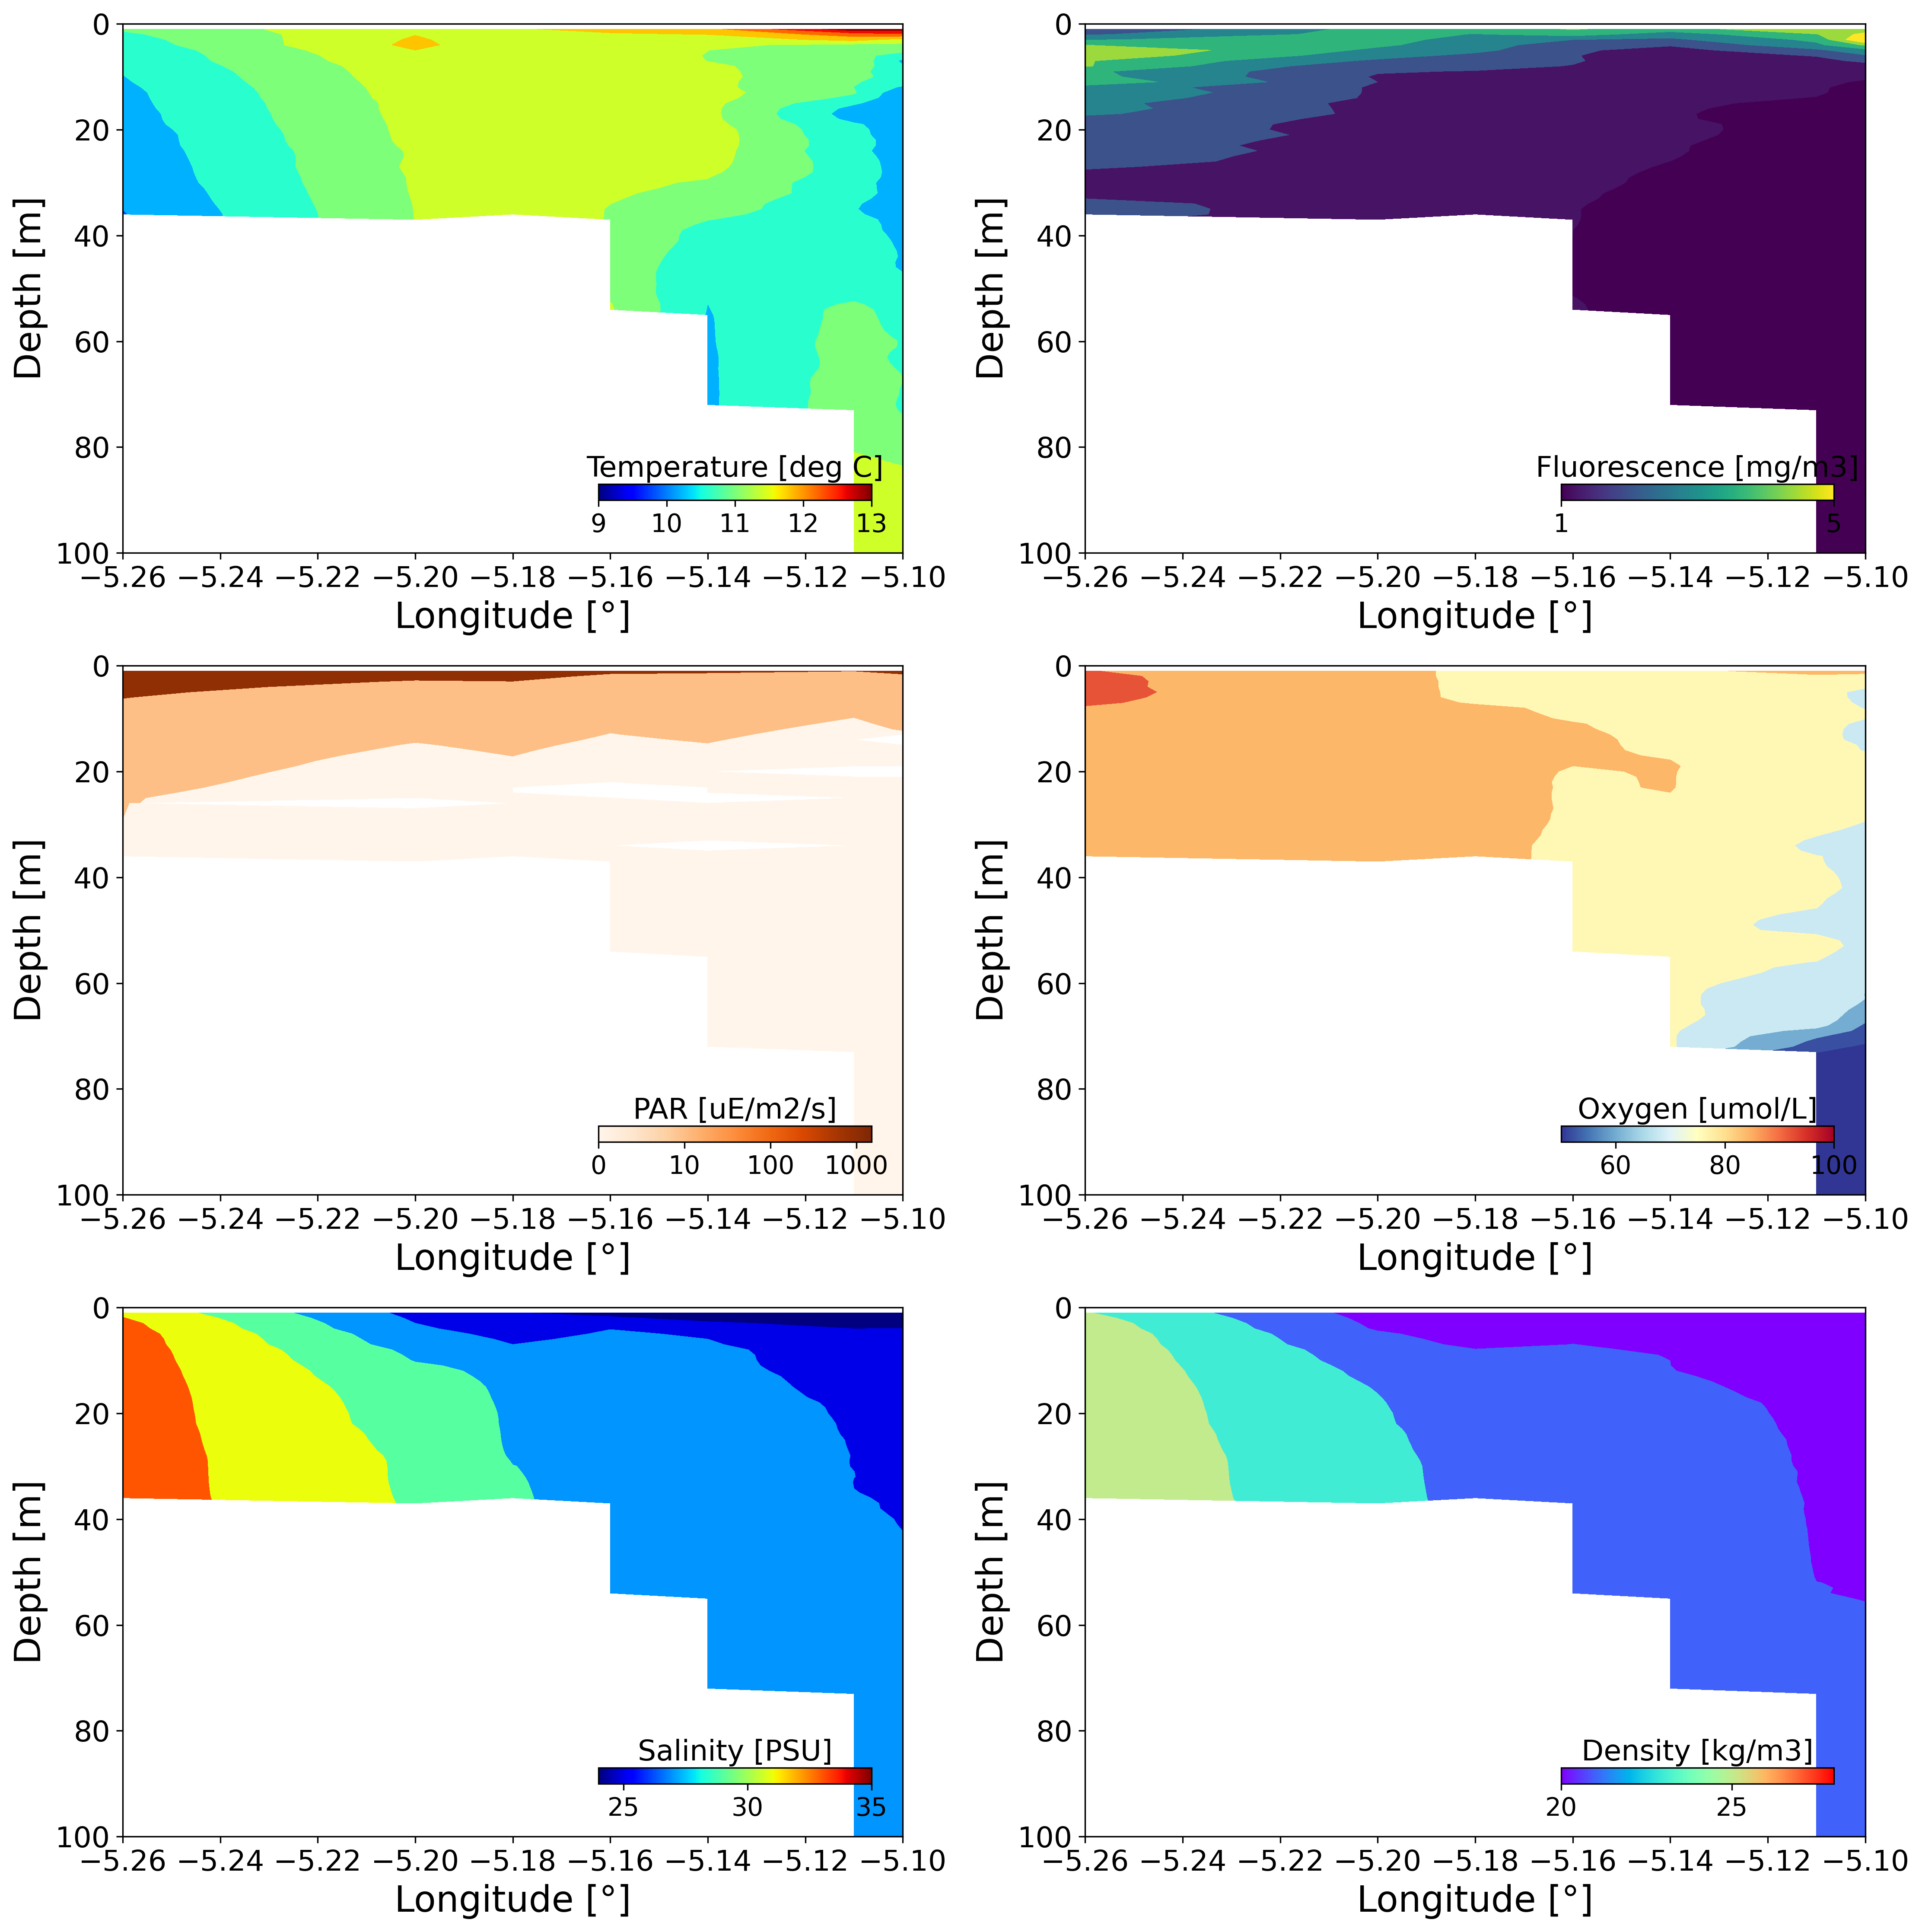

In [114]:
# Set the plot window up
fig, axes = plt.subplots(nrows=3,ncols=2,figsize=(15,15),dpi=300)

# temperature
axes[0,0].contourf(X, Y, all_temperature, cmap=cmap_temp, norm=norm_temp)
axes[0,0].set_ylim([0,100])
axes[0,0].invert_yaxis()
axes[0,0].set_xlabel('Longitude [°]', fontsize = 20)
axes[0,0].set_ylabel('Depth [m]', fontsize = 20)
axes[0,0].xaxis.set_tick_params(labelsize=16)
axes[0,0].yaxis.set_tick_params(labelsize=16)
axins = inset_axes(axes[0,0],
                    width="35%",  # width = 50% of parent_bbox width
                    height="3%",  # height : 5%
                    loc='lower right',
                    bbox_to_anchor=(-0.04, 0.1, 1, 1), # based on the right corner (bottom right)
                    bbox_transform=axes[0,0].transAxes,
                    borderpad=0)

cb = fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap_temp, norm=norm_temp), cax=axins, orientation='horizontal',ticks = [9,10,11,12,13])
cb.ax.set_xticklabels(['9','10','11','12','13']) 
cb.set_label(label='Temperature [deg C]', fontsize = 16)
cb.ax.xaxis.set_ticks_position('bottom')
cb.ax.xaxis.set_label_position('top')
cb.ax.tick_params(labelsize=14)

# fluorescence
axes[0,1].contourf(X, Y, all_fluorescence, cmap=cmap_fluo, norm=norm_fluo)
axes[0,1].set_ylim([0,100])
axes[0,1].invert_yaxis()
axes[0,1].set_xlabel('Longitude [°]', fontsize = 20)
axes[0,1].set_ylabel('Depth [m]', fontsize = 20)
axes[0,1].xaxis.set_tick_params(labelsize=16)
axes[0,1].yaxis.set_tick_params(labelsize=16)
axins = inset_axes(axes[0,1],
                    width="35%",  # width = 50% of parent_bbox width
                    height="3%",  # height : 5%
                    loc='lower right',
                    bbox_to_anchor=(-0.04, 0.1, 1, 1), # based on the right corner (bottom right)
                    bbox_transform=axes[0,1].transAxes,
                    borderpad=0)

cb = fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap_fluo, norm=norm_fluo), cax=axins, orientation='horizontal',ticks = [1,5,10])
# cb.ax.set_xticklabels(['0','3.3','6.6','10']) 
cb.set_label(label='Fluorescence [mg/m3]', fontsize = 16)
cb.ax.xaxis.set_ticks_position('bottom')
cb.ax.xaxis.set_label_position('top')
cb.ax.tick_params(labelsize=14)

# PAR
axes[1,0].contourf(X, Y, np.log10(all_par), cmap=cmap_par, norm=norm_par)  
axes[1,0].set_ylim([0,100])
axes[1,0].invert_yaxis()
axes[1,0].set_xlabel('Longitude [°]', fontsize = 20)
axes[1,0].set_ylabel('Depth [m]', fontsize = 20)
axes[1,0].xaxis.set_tick_params(labelsize=16)
axes[1,0].yaxis.set_tick_params(labelsize=16)

axins = inset_axes(axes[1,0],
                    width="35%",  # width = 50% of parent_bbox width
                    height="3%",  # height : 5%
                    loc='lower right',
                    bbox_to_anchor=(-0.04, 0.1, 1, 1), # based on the right corner (bottom right)
                    bbox_transform=axes[1,0].transAxes,
                    borderpad=0)

cb = fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap_par, norm=norm_par), cax=axins, orientation='horizontal',ticks = [0,np.log10(10),np.log10(100),np.log10(1000)])
cb.ax.set_xticklabels(['0','10','100','1000']) 
cb.set_label(label='PAR [uE/m2/s]', fontsize = 16)
cb.ax.xaxis.set_ticks_position('bottom')
cb.ax.xaxis.set_label_position('top')
cb.ax.tick_params(labelsize=14)

# oxygen
axes[1,1].contourf(X, Y, all_oxygen, cmap=cmap_oxygen, norm=norm_oxygen)
axes[1,1].set_ylim([0,100])
axes[1,1].invert_yaxis()
axes[1,1].set_xlabel('Longitude [°]', fontsize = 20)
axes[1,1].set_ylabel('Depth [m]', fontsize = 20)
axes[1,1].xaxis.set_tick_params(labelsize=16)
axes[1,1].yaxis.set_tick_params(labelsize=16)
axins = inset_axes(axes[1,1],
                    width="35%",  # width = 50% of parent_bbox width
                    height="3%",  # height : 5%
                    loc='lower right',
                    bbox_to_anchor=(-0.04, 0.1, 1, 1), # based on the right corner (bottom right)
                    bbox_transform=axes[1,1].transAxes,
                    borderpad=0)

cb = fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap_oxygen, norm=norm_oxygen), cax=axins, orientation='horizontal')#,ticks = [200,220,240,260,280,300])
#cb.ax.set_xticklabels(['200','220','240','260','280','300']) 
cb.set_label(label='Oxygen [umol/L]', fontsize = 16)
cb.ax.xaxis.set_ticks_position('bottom')
cb.ax.xaxis.set_label_position('top')
cb.ax.tick_params(labelsize=14)

# salinity
axes[2,0].contourf(X, Y, all_salinity, cmap=cmap_sal, norm=norm_sal)
axes[2,0].set_ylim([0,100])
axes[2,0].invert_yaxis()
axes[2,0].set_xlabel('Longitude [°]', fontsize = 20)
axes[2,0].set_ylabel('Depth [m]', fontsize = 20)
axes[2,0].xaxis.set_tick_params(labelsize=16)
axes[2,0].yaxis.set_tick_params(labelsize=16)

axins = inset_axes(axes[2,0],
                    width="35%",  # width = 50% of parent_bbox width
                    height="3%",  # height : 5%
                    loc='lower right',
                    bbox_to_anchor=(-0.04, 0.1, 1, 1), # based on the right corner (bottom right)
                    bbox_transform=axes[2,0].transAxes,
                    borderpad=0)

cb = fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap_sal, norm=norm_sal), cax=axins, orientation='horizontal')#,ticks = [31,32,33,34])
#cb.ax.set_xticklabels(['31','32','33','34']) 
cb.set_label(label='Salinity [PSU]', fontsize = 16)
cb.ax.xaxis.set_ticks_position('bottom')
cb.ax.xaxis.set_label_position('top')
cb.ax.tick_params(labelsize=14)

# density
axes[2,1].contourf(X, Y, all_density, cmap=cmap_density, norm=norm_density)
axes[2,1].set_ylim([0,100])
axes[2,1].invert_yaxis()
axes[2,1].set_xlabel('Longitude [°]', fontsize = 20)
axes[2,1].set_ylabel('Depth [m]', fontsize = 20)
axes[2,1].xaxis.set_tick_params(labelsize=16)
axes[2,1].yaxis.set_tick_params(labelsize=16)
axins = inset_axes(axes[2,1],
                    width="35%",  # width = 50% of parent_bbox width
                    height="3%",  # height : 5%
                    loc='lower right',
                    bbox_to_anchor=(-0.04, 0.1, 1, 1), # based on the right corner (bottom right)
                    bbox_transform=axes[2,1].transAxes,
                    borderpad=0)
cb = fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap_density, norm=norm_density), cax=axins, orientation='horizontal')#,ticks = [24,24.5,25,25.5,26])
#cb.ax.set_xticklabels(['24','24.5','25','25.5','26']) 
cb.set_label(label='Density [kg/m3]', fontsize = 16)
cb.ax.xaxis.set_ticks_position('bottom')
cb.ax.xaxis.set_label_position('top')
cb.ax.tick_params(labelsize=14)

fig.tight_layout()


In [ ]:
#plot bathymetry and stations locations

In [194]:
'''
from netCDF4 import Dataset

savedir = '/Users/jenmilsom/Desktop/Teaching_Exeter/GEO3463_Research_Cruise/2024_2025/'
loadname = 'GEBCO_2024_sub_ice_topo.nc'

nc = Dataset(savedir + loadname, 'r')
#print(nc.variables)
topo = nc.variables['elevation'][:]
lat = nc.variables['lat'][:]
lon = nc.variables['lon'][:]
nc.close()

print(topo.shape, topo.min(), topo.max())
print(lon.shape, lon.min(), lon.max())
print(lat.shape, lat.min(), lat.max())
'''

(43200, 86400) -10919 8627
(86400,) -179.99791666666667 179.99791666666667
(43200,) -89.99791666666667 89.99791666666667


In [9]:
'''
lonmin, lonmax, latmin, latmax = -7,-4,56,57

ind_lonmin = np.argmin(np.abs(lon - lonmin))
ind_lonmax = np.argmin(np.abs(lon - lonmax))
ind_latmin = np.argmin(np.abs(lat - latmin))
ind_latmax = np.argmin(np.abs(lat - latmax))

print(ind_lonmin, lon[ind_lonmin], lonmin)
print(ind_lonmax, lon[ind_lonmax], lonmax)
print(ind_latmin, lat[ind_latmin], latmin)
print(ind_latmax, lat[ind_latmax], latmax)

topo = np.copy(topo[ind_latmin:ind_latmax+1, ind_lonmin: ind_lonmax+1])
print(topo.shape, topo.min(), topo.max())
lon = np.copy(lon[ ind_lonmin: ind_lonmax+1])
lat = np.copy(lat[ind_latmin:ind_latmax+1])
print(lon.shape, lon.min(), lon.max())
print(lat.shape, lat.min(), lat.max())
np.save(savedir + 'topo_Lock_Etive',(topo, lon[None,:], lat[:,None]))
'''

savedir = '/Users/jenmilsom/Desktop/Teaching_Exeter/GEO3463_Research_Cruise/2024_2025/'
(topo, lon, lat) = np.load(savedir + 'topo_Lock_Etive.npy',allow_pickle=True)

lon, lat = lon[0,:], lat[:,0]
print(topo.shape, lon.shape, lat.shape)


(241, 721) (721,) (241,)


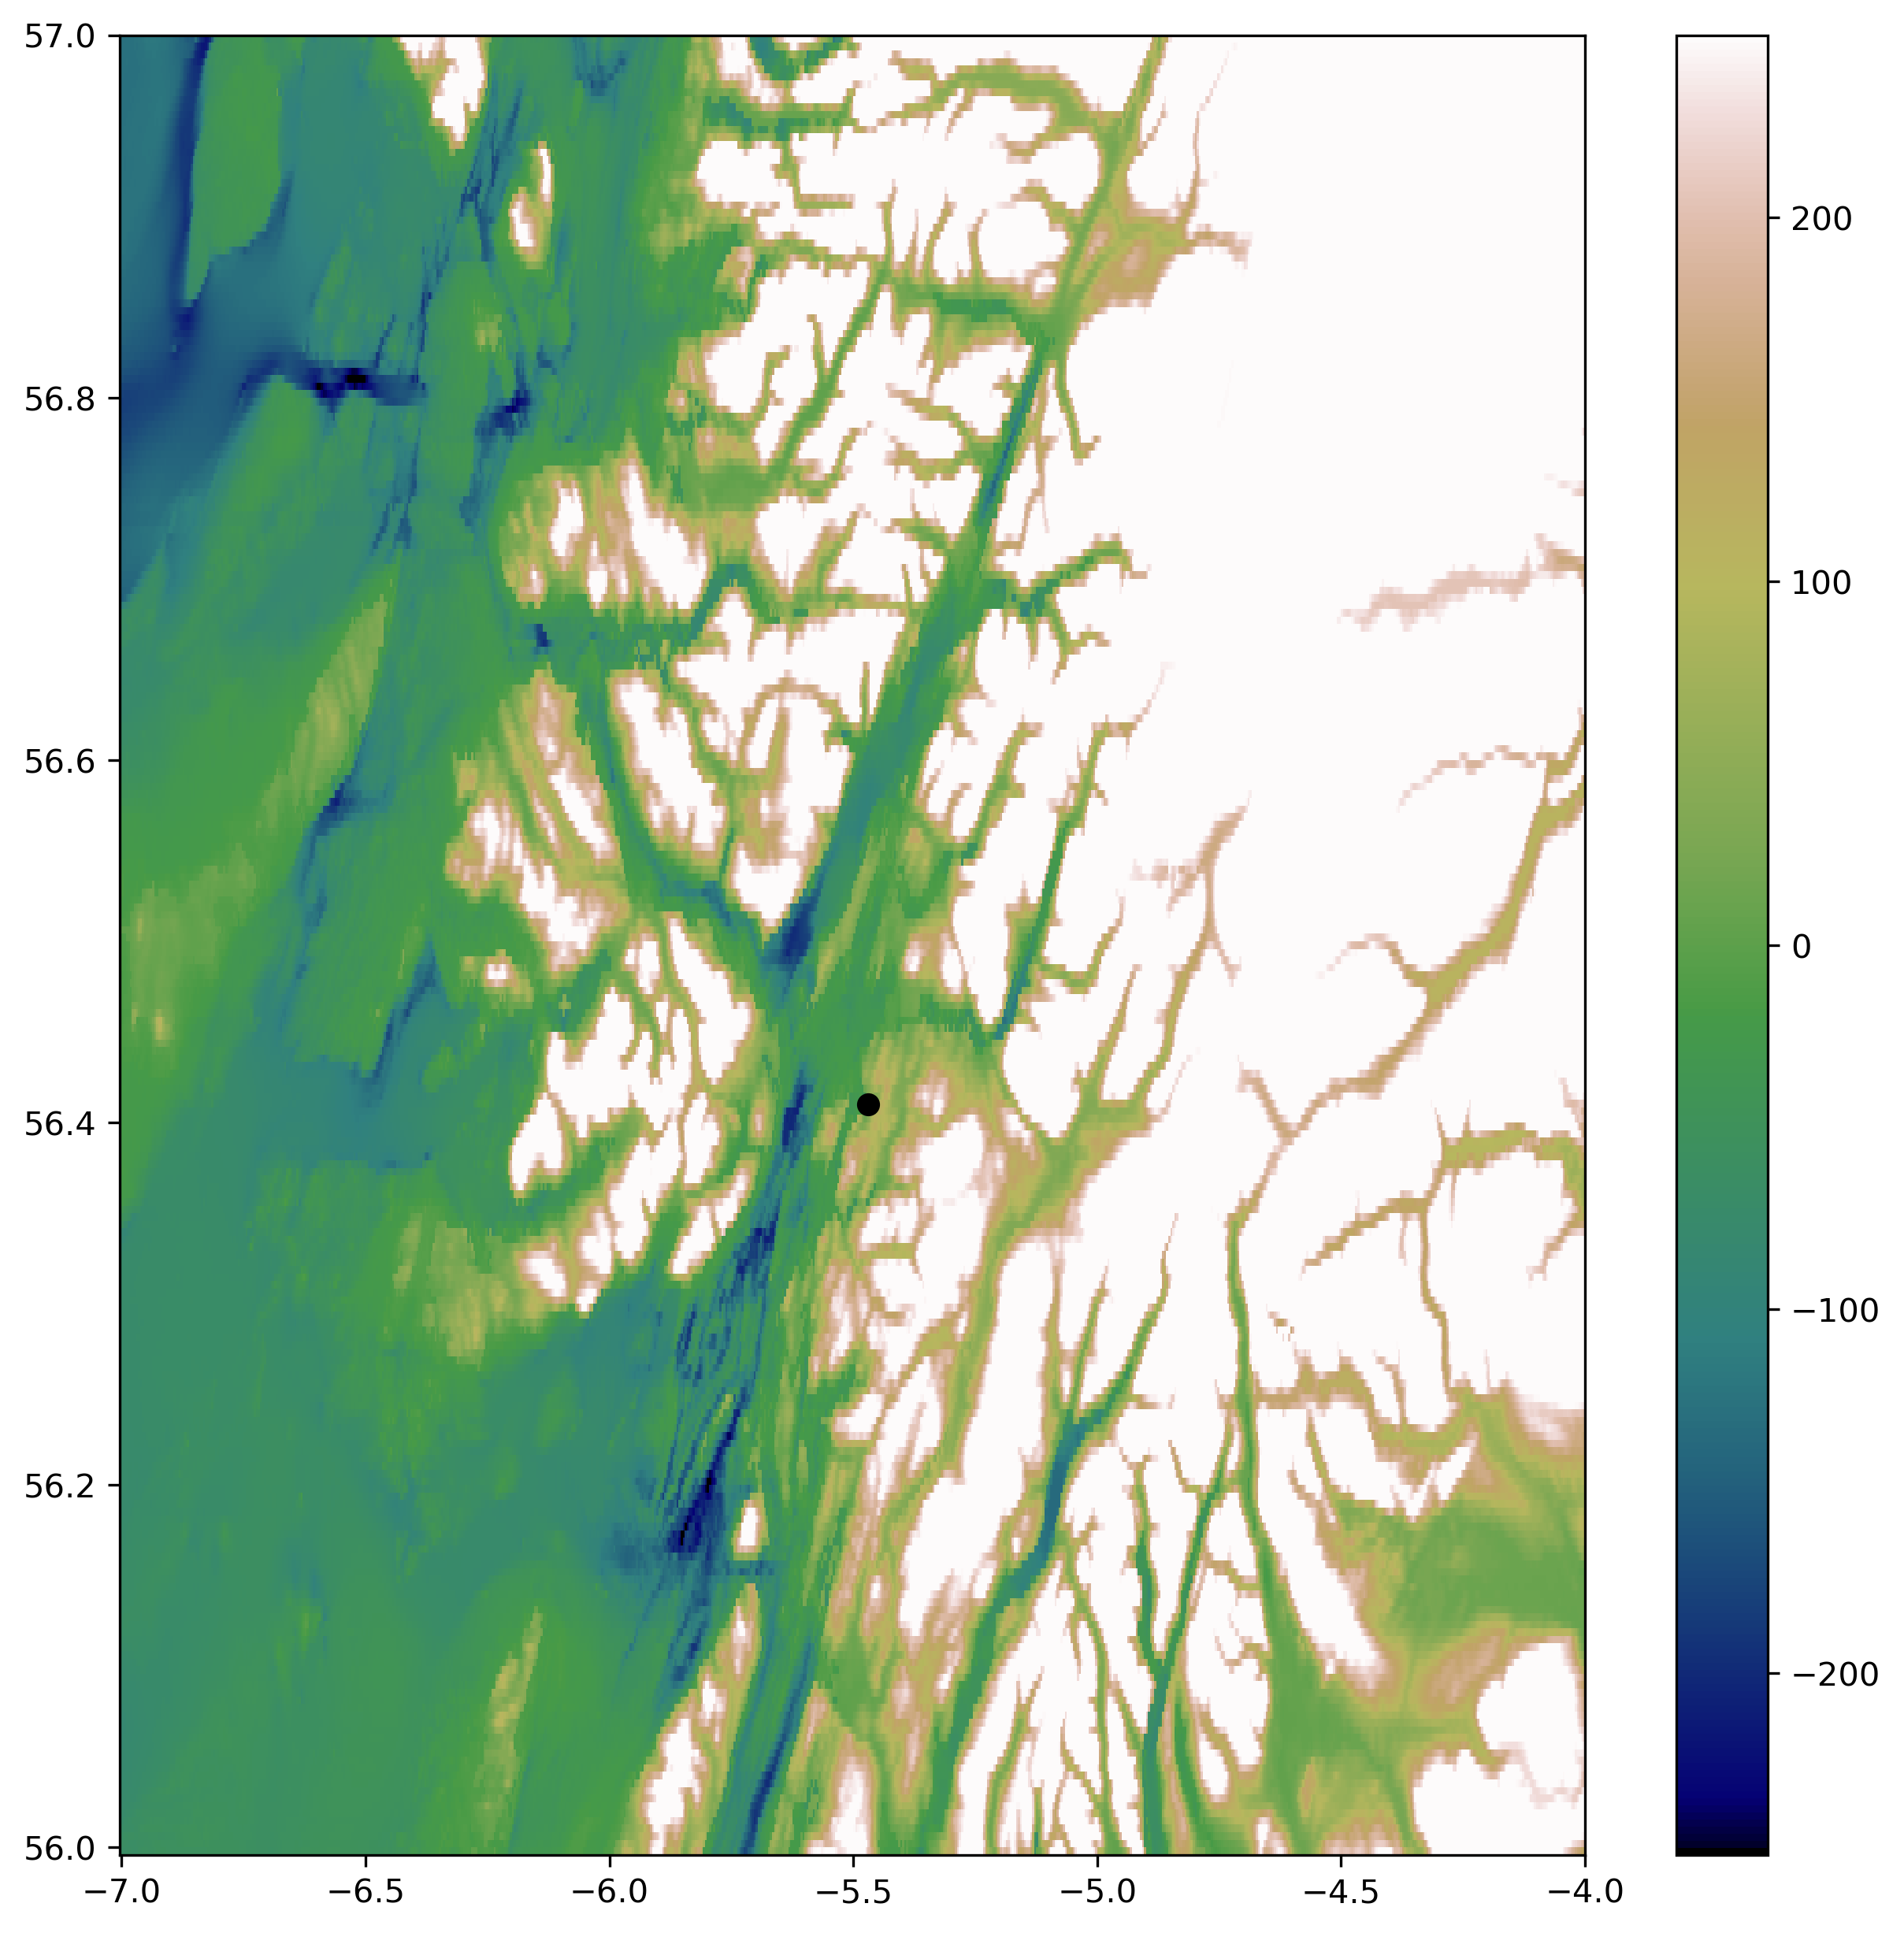

In [11]:
lon_oban, lat_oban = -5.47, 56.41
vmin, vmax = -250,250

fig, axes = plt.subplots(nrows=1,ncols=1,figsize=(10,10),dpi=300)

plt.pcolormesh(lon, lat, topo, cmap = plt.cm.gist_earth, vmin=vmin, vmax=vmax)
plt.plot(lon_oban,lat_oban, 'o',color='k',linewidth=15)
#plt.xlim([lonmin,lonmax])
#plt.ylim([latmin,latmax])
plt.colorbar()

plt.show()
plt.clf()
plt.cla()
plt.close()




In [200]:
np.save(savedir + 'topo_Lock_Etive',(topo, lon[None,:], lat[:,None]))